
# Skypa Systems Assignment - **Payment Probability Prediction.**


## Objective :
Predict each customer's payment probability using loan and repayment data.

##Dataset:
The dataset contains customer loan details, repayment behaviour, credit score, and demographic information over a 6-month period.


# **1. Data Cleaning:-**

In [ ]:
#1.1 Import required libraries and the dataset provided.

import pandas as pd
import numpy as np

df = pd.read_csv("/Data_6Months.csv")
df.head()


,Account_number,Principal_outstanding,dpd_days,dpd_bucket,prod_name,disbursal_date,disb_amt,tenor,roi,emi,...,final_veri_monthly_income,writeoff_date,gwo_amt,dpd_days_wo,source,loan_program_type,final_dbr,total_outstanding,Pmt_amount,month_end_date
0,1.151000e+11,0.0,4380.0,NCL,PL_SELF,27/01/09 00:00,105000.0,24.0,32.380001,6035.0,...,NaN,01-Jun-11,5884.0,146.0,NaN,STANDARD,NaN,NaN,0.0,2023-02-28
1,1.152000e+11,0.0,0.0,NCL,PL_SELF,12/09/08 00:00,200000.0,20.0,22.969999,12065.0,...,NaN,01-Sep-10,11844.0,149.0,NaN,STANDARD,NaN,NaN,0.0,2023-02-28
2,1.152000e+11,0.0,4046.0,NCL,PL_SELF,28/12/08 00:00,650000.0,36.0,22.219999,24993.0,...,NaN,01-May-12,24464.0,148.0,NaN,STANDARD,NaN,NaN,0.0,2023-02-28
3,2.152000e+11,760.0,4686.0,NCL,PL_SELF,24/03/08 00:00,155000.0,24.0,30.129999,8783.0,...,NaN,01-Aug-10,8560.0,149.0,NaN,STANDARD,NaN,NaN,0.0,2023-02-28
4,2.152000e+11,10.0,4015.0,NCL,PL_SELF,12/02/09 00:00,150000.0,36.0,32.759998,6542.0,...,NaN,01-Jun-12,10.0,147.0,NaN,STANDARD,NaN,NaN,0.0,2023-02-28


In [ ]:
# 1.2 Handle Missing values

# Check missing values
df.isnull().sum()

# Convert numeric columns
cols = [
    'Principal_outstanding', 'dpd_days', 'cibil_score',
    'final_veri_monthly_income', 'total_outstanding',
    'final_dbr', 'emi'
]
for col in cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Fill numeric missing values with median
for col in cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

# Fill categorical missing values with mode
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

# Convert date columns
date_cols = ['disbursal_date', 'month_end_date', 'writeoff_date']
for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], format='%Y-%m-%d', errors='coerce')

# Create Target variable
df['payment_flag'] = (df['Pmt_amount'] > 0).astype(int)

df.info()
# Outliers check
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 348151 entries, 0 to 348150
Data columns (total 32 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   Account_number             348151 non-null  float64       
 1   Principal_outstanding      348151 non-null  float64       
 2   dpd_days                   348151 non-null  float64       
 3   dpd_bucket                 348151 non-null  object        
 4   prod_name                  348151 non-null  object        
 5   disbursal_date             348151 non-null  datetime64[ns]
 6   disb_amt                   348151 non-null  float64       
 7   tenor                      348151 non-null  float64       
 8   roi                        348151 non-null  float64       
 9   emi                        348151 non-null  float64       
 10  cibil_score                348151 non-null  float64       
 11  residence_city             348151 non-null  object  

,Account_number,Principal_outstanding,dpd_days,disbursal_date,disb_amt,tenor,roi,emi,cibil_score,pincode,...,writeoff_date,gwo_amt,dpd_days_wo,final_dbr,total_outstanding,Pmt_amount,month_end_date,payment_flag,predicted_probability,predicted_class
count,3.481510e+05,3.481510e+05,348151.000000,348151,3.481510e+05,348151.000000,348151.000000,348151.000000,3.481510e+05,348151.000000,...,0,3.481510e+05,348151.000000,348151.000000,3.481510e+05,3.481510e+05,348151,348151.000000,348151.000000,348151.000000
mean,6.345040e+13,2.382958e+05,851.143771,2018-05-18 09:20:38.700449280,3.432110e+05,50.957806,28.409250,11532.010439,7.037875e+02,321574.233683,...,NaT,2.525021e+05,146.686274,50.715874,3.106319e+05,2.088536e+03,2023-05-16 06:08:02.997320192,0.088131,0.088190,0.079632
min,0.000000e+00,0.000000e+00,0.000000,1970-01-01 00:00:00,0.000000e+00,0.000000,0.000000,0.000000,-1.000000e+00,0.000000,...,NaT,0.000000e+00,0.000000,0.000000,0.000000e+00,-1.390000e+05,2023-02-28 00:00:00,0.000000,0.000006,0.000000
25%,1.280231e+13,8.443129e+04,394.000000,2017-10-24 00:00:00,1.600050e+05,48.000000,24.000000,5878.000000,7.300000e+02,0.000000,...,NaT,9.607560e+04,147.000000,45.150000,3.000050e+05,0.000000e+00,2023-03-31 00:00:00,0.000000,0.036000,0.000000
50%,5.080231e+13,1.822289e+05,756.000000,2018-10-02 00:00:00,2.743940e+05,49.000000,28.500000,9541.000000,7.680000e+02,364005.000000,...,NaT,1.945823e+05,148.000000,51.800000,3.000050e+05,0.000000e+00,2023-05-31 00:00:00,0.000000,0.072537,0.000000
75%,9.880221e+13,3.402643e+05,1152.000000,2019-08-21 00:00:00,4.751720e+05,61.000000,33.000000,15390.000000,7.850000e+02,521228.000000,...,NaT,3.558446e+05,149.000000,59.880000,3.000050e+05,0.000000e+00,2023-06-30 00:00:00,0.000000,0.129088,0.000000
max,3.028023e+14,2.472878e+06,5838.000000,2022-12-31 00:00:00,3.065511e+06,62.000000,60.000000,111210.000000,2.518432e+06,844101.000000,...,NaT,2.581528e+06,1456.000000,3500.000000,1.007615e+07,1.471654e+06,2023-07-31 00:00:00,1.000000,0.926331,1.000000
std,5.847918e+13,2.161871e+05,681.113614,NaN,2.433626e+05,9.997408,6.450564,7412.062340,1.045556e+04,248971.860182,...,NaN,2.189468e+05,12.231641,21.412084,1.338830e+05,1.457350e+04,NaN,0.283486,0.064451,0.270723


## Data Quality Summary:

The dataset required preprocessing to ensure consistency and usability for analysis and modelling.

- Numeric columns such as dpd_days, cibil_score, income, EMI, and outstanding amounts contained non-numeric values, which were converted using appropriate type casting with error handling
- Missing values introduced during conversion were handled using median imputation to reduce the impact of outliers
- Categorical columns with missing values were filled using the mode to preserve the most frequent category
- Date columns including disbursal_date, month_end_date, and writeoff_date were converted into datetime format for time-based analysis
- A target variable (payment_flag) was created based on whether a payment was made (Pmt_amount > 0)
- Data types were verified using df.info()
- Outliers were checked using summary statistics (df.describe()), no extreme anomalies affecting analysis were observed

Post-cleaning, the dataset had no critical missing values in the selected features and was suitable for further analysis and modelling.

---



# **2**. **Exploratory Data Analysis :-**

# 2.1 Account distribution

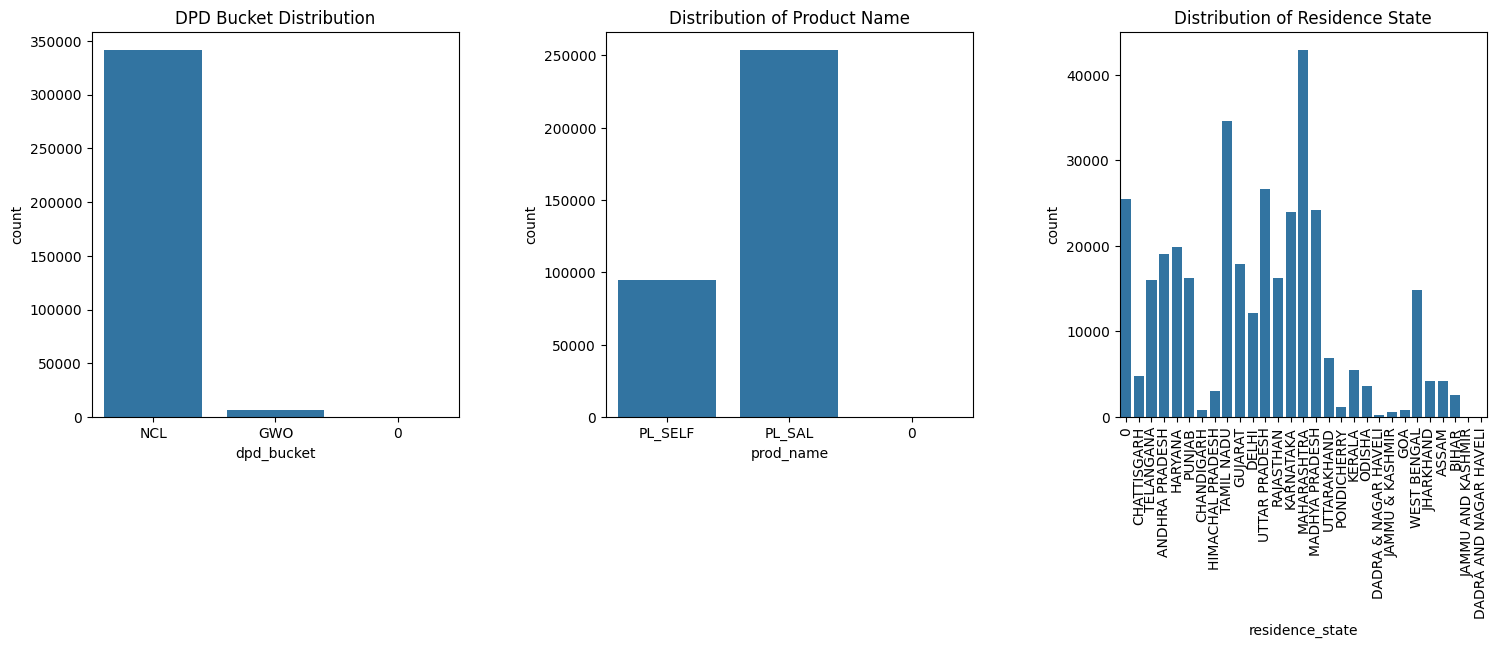

In [ ]:

import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 2.1.1 DPD distribution
sns.countplot(x='dpd_bucket', data=df, ax=axes[0])
axes[0].set_title("DPD Bucket Distribution")
axes[0].tick_params(axis='x')

# 2.1.2 Product name distribution
sns.countplot(x='prod_name', data=df, ax=axes[1])
axes[1].set_title("Distribution of Product Name")
axes[1].tick_params(axis='x')

# 2.1.3 Residence State distribution
sns.countplot(x='residence_state', data=df, ax=axes[2])
axes[2].set_title("Distribution of Residence State")
axes[2].tick_params(axis='x', rotation=90)

# Adjust spacing between plots
plt.subplots_adjust(wspace=0.4)
plt.show()


**EDA Insights(Account Distribution):-**

* *DPD Bucket Distribution* : It looks like a huge chunk of our accounts are actually in default ('NCL'), which is a pretty big red flag for our       portfolio.
* *Product Name Distribution* : We're really heavy on personal loans       ('PL_SELF'), which is our most offered product by far.
* *Residence State Distribution* : Our customers seem to be clustered in just a few key states, showing we might have a concentrated market presence.


# 2.2 Payment Trend

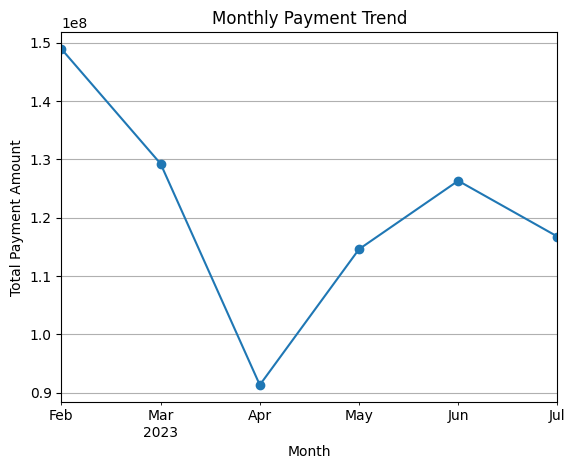

Month-over-Month % Change:
month
2023-02          NaN
2023-03   -13.215074
2023-04   -29.347769
2023-05    25.487878
2023-06    10.238257
2023-07    -7.568057
Freq: M, Name: Pmt_amount, dtype: float64


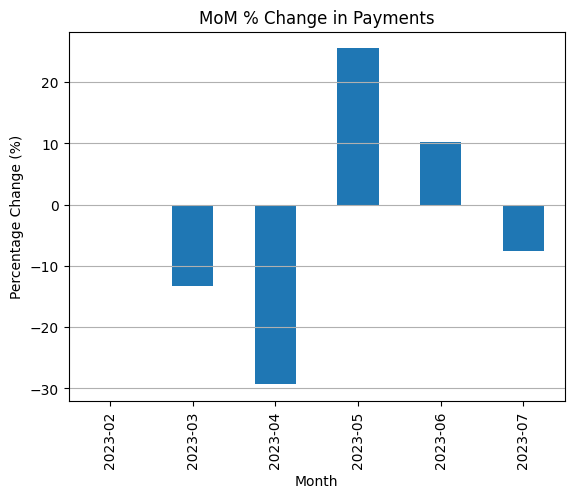

In [ ]:
# 2.2.1 Month over Month trends in pmt_amount

# Create month column
df['month'] = df['month_end_date'].dt.to_period('M')

#calculate total payment per month
monthly = df.groupby('month')['Pmt_amount'].sum()
# Line plot (Trend)
monthly.plot(marker='o')
plt.title("Monthly Payment Trend")
plt.xlabel("Month")
plt.ylabel("Total Payment Amount")
plt.grid(True)
plt.show()

# MOM(Month-Over-Month) Change % calculation
mom_change = monthly.pct_change() * 100
print("Month-over-Month % Change:")
print(mom_change)

# Bar plot (Rate of change)
mom_change.plot(kind='bar')
plt.title("MoM % Change in Payments")
plt.xlabel("Month")
plt.ylabel("Percentage Change (%)")
plt.grid(axis='y')
plt.show()

month_end_date
2023-02-28    5704
2023-03-31    5030
2023-04-30    4114
2023-05-31    4915
2023-06-30    4865
2023-07-31    4869
Name: Account_number, dtype: int64


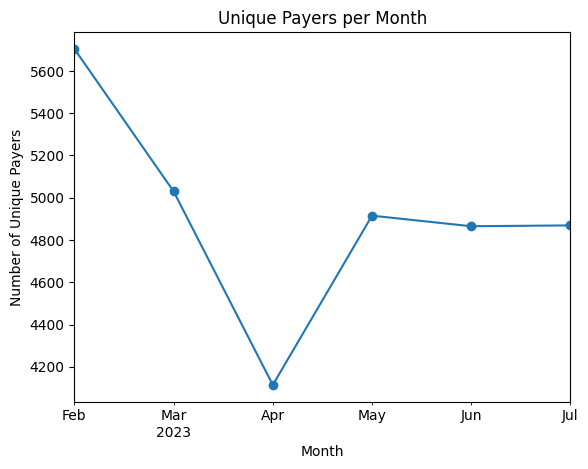

In [ ]:
# 2.2.2 No.of Unique payers per month

#filter only paying customers
payers_df = df[df['Pmt_amount'] > 0]

# group by month and count unique customers
unique_payers = payers_df.groupby('month_end_date')['Account_number'].nunique()
print(unique_payers)

#plot
unique_payers.plot(marker='o')
plt.title("Unique Payers per Month")
plt.xlabel("Month")
plt.ylabel("Number of Unique Payers")
plt.show()

Total Paid Amount: 727126055.3500001
Active Pool (Total Outstanding): 5924075088.340001
Delinquent Pool (Total Outstanding): 102222718786.70001
Active Customers: 4292
Delinquent Customers: 59062


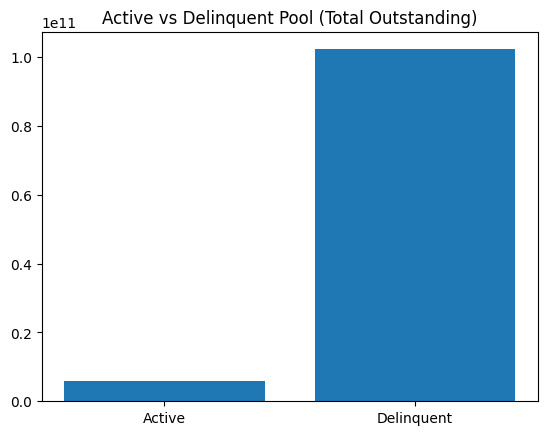

In [ ]:
# 2.2.3 Paid V/S unpaid plot

#calculating the total paid amounts
total_paid = df['Pmt_amount'].sum()
print("Total Paid Amount:", total_paid)

# Active pool
active_pool = df[df['dpd_days'] == 0]['total_outstanding'].sum()
# Delinquent pool
delinquent_pool = df[df['dpd_days'] > 0]['total_outstanding'].sum()

print("Active Pool (Total Outstanding):", active_pool)
print("Delinquent Pool (Total Outstanding):", delinquent_pool)

# count of customers in each pool
active_count = df[df['dpd_days'] == 0]['Account_number'].nunique()
delinquent_count = df[df['dpd_days'] > 0]['Account_number'].nunique()
print("Active Customers:", active_count)
print("Delinquent Customers:", delinquent_count)

#plot
pools = [active_pool, delinquent_pool]
labels = ['Active', 'Delinquent']
plt.bar(labels, pools)
plt.title("Active vs Delinquent Pool (Total Outstanding)")
plt.show()

**EDA Insights(Payment Trends):-**


* Monthly Payment Trend: Payments have been a bit of a rollercoaster, with a noticeable dip in April before bouncing back strong in May and June.
* MoM % Change in Payments: The biggest hit to payments happened in April, but May really turned things around with a solid jump.
* Unique Payers per Month: We saw fewer individual customers making payments from February to April, though that number has mostly held steady since then.
* Active vs Delinquent Pool: The overwhelming majority of our outstanding loans, and a large number of customers, are actually in the delinquent category, signaling a significant risk.





---



# **3. Model Building**

In [ ]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# Feature engineering
features = [
    'emi',
    'cibil_score',
    'final_veri_monthly_income',
    'dpd_days',
    'total_outstanding'
]
X = df[features]
y = df['payment_flag']

# Train-Test Split
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Model Training
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

#Model Evaluation
y_pred = model.predict_proba(X_test)[:,1]
roc_auc = roc_auc_score(y_test, y_pred)
print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.7366918100331561


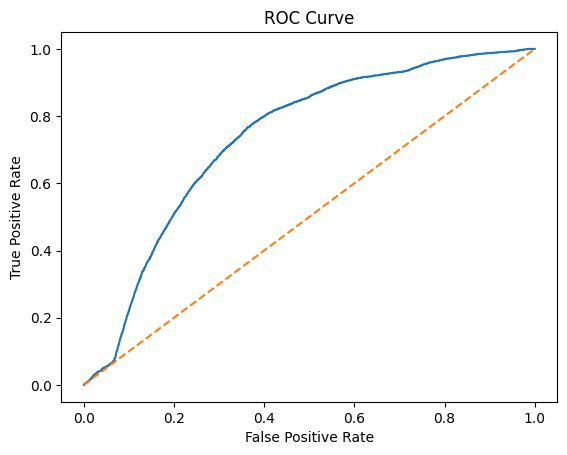

In [ ]:
#ROC_AUC curve plot

from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_pred)

plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], '--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

# Prediction Results:-

In [ ]:
# Predicting results For TEST Dataset

# Predict probabilities
y_test_pred_prob = model.predict_proba(X_test)[:, 1]
threshold = 0.2
y_test_pred_class = (y_test_pred_prob >= threshold).astype(int)

# Create results dataframe
results_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted_Probability': y_test_pred_prob,
    'Predicted_Class': y_test_pred_class
})
# Show first 30 rows
print("Test Set Predictions (First 30 rows):")
print(results_df.head(30))


# Show total records
print("\nTotal Test Records:", len(results_df))
# Show summary
print("\nPrediction Summary:")
print(results_df['Predicted_Class'].value_counts())
# Save FULL test predictions to file
results_df.to_csv("test_predictions_full.csv", index=False)


Test Set Predictions (First 30 rows):
    Actual  Predicted_Probability  Predicted_Class
0        0               0.070969                0
1        0               0.213483                1
2        0               0.000189                0
3        0               0.176028                0
4        1               0.044527                0
5        0               0.069329                0
6        0               0.083419                0
7        0               0.072268                0
8        1               0.117987                0
9        0               0.070355                0
10       0               0.220680                1
11       0               0.095143                0
12       0               0.021942                0
13       0               0.079368                0
14       0               0.029880                0
15       1               0.239492                1
16       1               0.215943                1
17       0               0.002663           

NOTE:- Predictions are shown for 30 samples of the test dataset for readability.
The complete prediction results have been generated and can be exported to file named 'test_predictions_full.csv'
for further analysis.

The model initially predicted very few positive cases using the default threshold of 0.5, indicating class imbalance(Non-paying dominate).
To improve interpretability, the threshold was adjusted to 0.2, resulting in a more balanced prediction of paying customers.
This helps better identify potential payers for business decision-making.



In [ ]:
# Predicting results For FULL dataset (Business interpretation purpose).


# Scale full dataset
X_full_scaled = scaler.transform(X)
# Predict probabilities
y_full_pred_prob = model.predict_proba(X_full_scaled)[:, 1]
threshold = 0.2
y_full_pred_class = (y_full_pred_prob >= threshold).astype(int)

# Adding predictions to dataframe
df['predicted_probability'] = y_full_pred_prob
df['predicted_class'] = y_full_pred_class

# sample 30 records shown
print("Sample Full Dataset Predictions:")
print(df[['Account_number', 'predicted_probability', 'predicted_class']].head(30))

# Save file
df.to_csv("full_dataset_predictions.csv", index=False)

Sample Full Dataset Predictions:
    Account_number  predicted_probability  predicted_class
0     1.151000e+11               0.000089                0
1     1.152000e+11               0.238170                1
2     1.152000e+11               0.000212                0
3     2.152000e+11               0.000052                0
4     2.152000e+11               0.000176                0
5     2.152000e+11               0.000281                0
6     6.151000e+11               0.000079                0
7     6.151000e+11               0.000091                0
8     6.152000e+11               0.236614                1
9     6.152000e+11               0.228990                1
10    6.152000e+11               0.234564                1
11    6.152000e+11               0.000079                0
12    8.152000e+11               0.000034                0
13    9.150000e+11               0.223373                1
14    1.225200e+12               0.220812                1
15    1.415000e+12     

Predictions were generated for the full dataset to identify customers likely to make payments.
This can be used for prioritizing collection efforts and segmenting customers based on risk, while model performance was evaluated using the test set (above).

Feature Importance: 
emi                          0.098917
total_outstanding            0.045566
cibil_score                 -0.001694
final_veri_monthly_income   -0.024258
dpd_days                    -1.257114
dtype: float64


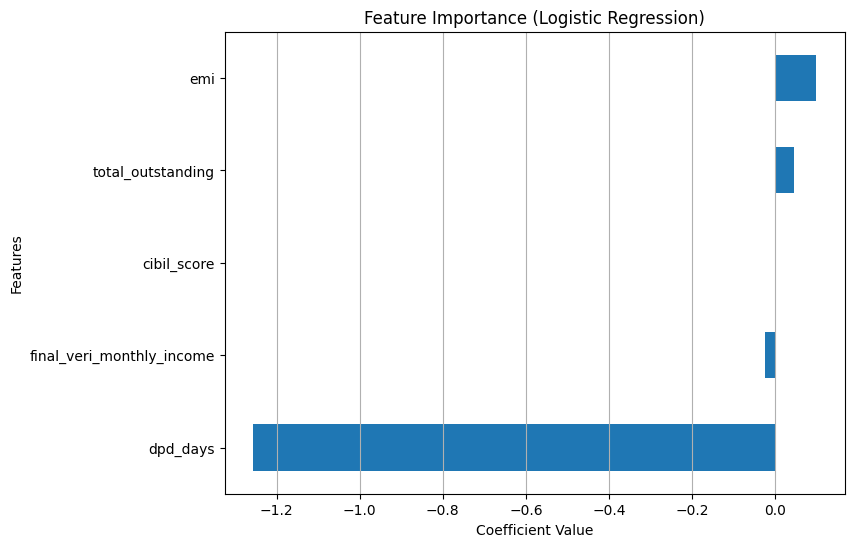

In [ ]:
# Feature Importance

# Create feature importance series
importance = pd.Series(model.coef_[0], index=features)

# Sort values
importance_sorted = importance.sort_values(ascending=False)
print("Feature Importance: ")
print(importance_sorted)

# Plot
plt.figure(figsize=(8,6))
importance_sorted.sort_values().plot(kind='barh')
plt.title("Feature Importance (Logistic Regression)")
plt.xlabel("Coefficient Value")
plt.ylabel("Features")
plt.grid(axis='x')
plt.show()



---



## Decision Tree Model (for model performance comparision)

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict_proba(X_test)[:,1]

from sklearn.metrics import roc_auc_score
roc_auc_dt = roc_auc_score(y_test, y_pred_dt)

print("Decision Tree ROC-AUC:", roc_auc_dt)


Decision Tree ROC-AUC: 0.7856047534758377




---



## Model Summary:



*  Model used: Logistic Regression
*  Evaluation metric: ROC-AUC
*  The model predicts probability of payment (binary classification)
*   A Decision Tree model was also tested to capture non-linear relationships.
However, Logistic Regression provided comparable performance with better interpretability, so it was chosen as the primary model.
*  ROC-AUC score indicates how well the model distinguishes between paying and non-paying customers


**This Logistic Regression model achieved a ROC-AUC score of approximately 0.737, indicating a fair ability to distinguish between paying and non-paying customers, with dpd_days being the most influential factor.**



*Important Features:*
- dpd_days
- cibil_score
- monthly income
- EMI


---



## Conclusion:

- Customers with higher dpd_days are less likely to make payments
- Higher income and better credit scores increase payment probability
- The model can help identify high-risk customers for targeted recovery




Business Recommendations:

* Focus recovery efforts on high DPD customers, Offer flexible plans to medium-risk customers

*  Use ML model for early risk detection


---





## Next Steps:

- Incorporate additional behavioural features such as past payment patterns and loan tenure.
- Use more advanced models like Random Forest or Gradient Boosting to improve prediction performance.
- Continuously monitor model performance and retrain with updated data for better accuracy.


---


